In [1]:
import osmnx as ox
import geopandas as gpd
import networkx as nx
import pandas as pd
from shapely.geometry import Point

## 1. Data Loading and Structure

- Load the street network with OSMnx and project to metric CRS for accurate spatial analysis.
- Import sensor noise time series from Open Data BCN.
- Keep spatial (network) and temporal (sensors) data separate for clear feature engineering later.


### 1.1 Spatial Data (OSMnx)

In [2]:
# 1. Load spatial data
G = ox.graph_from_place("Barcelona, Spain", network_type="drive")

# 2. Convert graph to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)

# 3. Project to metric CRS (ETRS89 / UTM zone 31N)
nodes = nodes.to_crs(epsg=25831)
edges = edges.to_crs(epsg=25831)

# Quick check
print(edges.columns)
print(nodes.columns)

Index(['osmid', 'oneway', 'lanes', 'name', 'highway', 'maxspeed', 'reversed',
       'length', 'geometry', 'access', 'junction', 'ref', 'width', 'est_width',
       'tunnel', 'bridge', 'service'],
      dtype='object')
Index(['y', 'x', 'street_count', 'ref', 'highway', 'geometry'], dtype='object')


### 1.2 Temporal Data (Open Data BCN)

In [3]:
noise_df = pd.read_parquet("../data/interim/noise_hourly_avg.parquet")

# Basic aggregation per sensor (ignore time for now)
noise_mean = (
    noise_df.groupby("sensor_id")
    .agg(avg_noise=('avg_noise_level', 'mean'),
         max_noise=('avg_noise_level', 'max'),
         p95_noise=('avg_noise_level', lambda x: x.quantile(0.95)),
         std_noise=('avg_noise_level', 'std'),
         n_meas=('num_measurements', 'sum'))
    .reset_index()
)

noise_mean.head()

,sensor_id,avg_noise,max_noise,p95_noise,std_noise,n_meas
0,186,65.366429,77.4,71.910,4.371013,280
1,187,63.641071,72.1,68.505,3.633150,280
2,206,59.071007,69.6,65.000,3.520876,576
3,207,63.500347,74.2,68.725,3.200402,576
4,208,59.998370,80.3,66.645,4.699822,552


## 2. Compute Network Metrics

In [ ]:
# ----------------------------------------------------
# 1. BETWEENNESS CENTRALITY
# ----------------------------------------------------
# -> Measures how often a node lies on the shortest paths between others.
# -> High betweenness = high through-traffic potential = strong noise emission areas.
# -> Think of it as "bottleneck" importance — busy corridors where flow concentrates.
betweenness = nx.betweenness_centrality(G, weight='length', normalized=True)
nx.set_node_attributes(G, betweenness, "betweenness")  # store in the graph

# ----------------------------------------------------
# 2. CLOSENESS CENTRALITY
# ----------------------------------------------------
# -> Measures how close a node is (in distance) to all others in the network.
# -> High closeness = more accessible locations = urban cores with higher activity.
# -> Implication: often associated with higher average noise due to mobility & density.
closeness = nx.closeness_centrality(G, distance='length')
nx.set_node_attributes(G, closeness, "closeness")

# ----------------------------------------------------
# 3. INTERSECTION DENSITY (micro-scale urban friction)
# ----------------------------------------------------
# -> Using nodes' spatial distribution, we count how many intersections exist
#    within a defined radius (here 150 m).
# -> Denser intersections = more braking/acceleration/stopping traffic points,
#    which increase mechanical and tire noise variability.
buffer_distance = 150  # meters
nodes, edges = ox.graph_to_gdfs(G)
nodes = nodes.to_crs(epsg=25831)  # metric CRS (for distance ops)
nodes['intersections_150m'] = nodes.geometry.apply(
    lambda p: sum(nodes.distance(p) <= buffer_distance)
)

# ----------------------------------------------------
# 4. AGGREGATE RESULTS INTO A METRICS TABLE
# ----------------------------------------------------
# We'll keep only relevant columns for joining later with noise sensors.
nodes_metrics = nodes[[
    'betweenness',
    'closeness',
    'street_count',       # number of streets meeting at node (OSMnx precomputed)
    'intersections_150m',
    'geometry'
]]

# ----------------------------------------------------
# 5. SAVE RESULTS
# ----------------------------------------------------
# Export so they can be spatially joined with real noise or sensor data later.
nodes_metrics.to_file("barcelona_nodes_metrics_with_comments.gpkg", driver="GPKG")

# ----------------------------------------------------
# SUMMARY:
# betweenness        → road flow intensity (traffic-driven noise)
# closeness          → accessibility / centrality (activity-related noise)
# intersections_150m → intersection friction (mechanical bursts and stops)
# street_count       → connectivity complexity (propagation & reflection factors)
# ----------------------------------------------------


## 3. Merge Network Metrics with Sensor Data

In [32]:
# Load sensor_location dataset
sensor_location = pd.read_csv("../data/raw/sensors/XarxaSoroll_EquipsMonitor_Instal.csv")
sensor_location.rename(columns={"Id_Instal": "sensor_id"}, inplace=True)

# Merge dataset
noise_mean_location = noise_mean.merge(sensor_location[["sensor_id", "Latitud", "Longitud"]], on='sensor_id', how='left')

# Convert 'Longitud' and 'Latitud' data to shapely Point
noise_mean_location['geometry'] = [
    Point(xy) for xy in zip(noise_mean_location['Longitud'], noise_mean_location['Latitud'])
]

# Convert to GeoDataFrame
noise_mean_geo = gpd.GeoDataFrame(
    noise_mean_location, geometry='geometry', crs='EPSG:4326'  # WGS84 (lat/lon)
)

# Barcelona = ETRS89 / UTM zone 31N (EPSG:25831)
noise_mean_geo = noise_mean_geo.to_crs(epsg=25831)

# 5️⃣ Check results
noise_mean_geo.head()

,sensor_id,avg_noise,max_noise,p95_noise,std_noise,n_meas,Latitud,Longitud,geometry
0,186,65.366429,77.4,71.910,4.371013,280,41.395450,2.152752,POINT (429172.394 4583003.569)
1,187,63.641071,72.1,68.505,3.633150,280,41.396156,2.151563,POINT (429073.764 4583082.921)
2,206,59.071007,69.6,65.000,3.520876,576,41.380127,2.176924,POINT (431176.967 4581282.954)
3,207,63.500347,74.2,68.725,3.200402,576,41.378273,2.173348,POINT (430875.987 4581079.972)
4,208,59.998370,80.3,66.645,4.699822,552,41.384925,2.182772,POINT (431670.986 4581810.993)


In [42]:
# 1. LOAD YOUR NODE METRICS FROM STEP 2
nodes_metrics = gpd.read_file("barcelona_nodes_metrics_with_comments.gpkg")
nodes_metrics = nodes_metrics.to_crs(noise_mean_geo.crs)

nodes_metrics.head()

,osmid,betweenness,closeness,street_count,intersections_150m,geometry
0,21638845,0.001768,0.000140,3,5,POINT (432071.186 4580160.408)
1,21638865,0.000000,0.000000,1,26,POINT (432319.661 4580899.827)
2,21638867,0.003475,0.000159,4,32,POINT (432179.146 4581060.543)
3,21638868,0.002421,0.000158,3,42,POINT (432266.183 4581085.321)
4,21638869,0.002819,0.000158,4,35,POINT (432323.988 4581101.635)


In [43]:
# 2. SPATIAL JOIN: find the nearest node for each sensor
#    This links each sensor to the most representative network node (intersection)
#    → thus inheriting its topological and structural attributes.
sensors = noise_mean_geo.sjoin_nearest(
    nodes_metrics[['betweenness', 'closeness',
                   'street_count', 'intersections_150m', 'geometry']],
    distance_col='dist_to_node'
)

# 3. DEAL WITH DISTANCE ATTRIBUTE
#    'dist_to_node' tells you how far each sensor is from its nearest intersection.
#    You can use this as a feature — proximity to intersections often implies
#    higher braking/acceleration and traffic-related noise.
print(sensors[['avg_noise', 'betweenness', 'closeness',
                      'street_count', 'intersections_150m', 'dist_to_node']].head())

# 5. SAVE THE ENRICHED SENSOR DATA
#    Now each sensor point includes all relevant network-based predictors.
sensors.to_file("barcelona_sensors_enriched.gpkg", driver="GPKG")

# -------------------------------------------------------------------------
# INTERPRETATION: WHY THIS JOIN MATTERS
# -------------------------------------------------------------------------
# - Each noise sensor now "inherits" the structural characteristics of the
#   network around it — how connected, central, or dense that environment is.
# - Betweenness  -> indicators of vehicle flow intensity
# - Closeness    -> accessibility (liveliness of area)
# - Street_count -> structural complexity (more nearby streets = more reflections)
# - intersections_100m -> high traffic friction zones (stops, signals)
# - dist_to_node -> physical distance to main traffic corridor (attenuation factor)
# -------------------------------------------------------------------------


   avg_noise  betweenness  closeness  street_count  intersections_150m  \
0  65.366429     0.004536   0.000215             3                   5   
1  63.641071     0.004711   0.000216             3                   4   
2  59.071007     0.001997   0.000165             3                  19   
3  63.500347     0.000389   0.000153             3                   7   
4  59.998370     0.001299   0.000172             3                   9   

   dist_to_node  
0     42.156877  
1     10.602728  
2     22.243886  
3      7.452369  
4     25.313819  


## 4. Feature Engineering

In [34]:
edges.columns

Index(['osmid', 'oneway', 'lanes', 'name', 'highway', 'maxspeed', 'reversed',
       'length', 'geometry', 'access', 'junction', 'ref', 'width', 'est_width',
       'tunnel', 'bridge', 'service', 'maxspeed_clean', 'lanes_clean'],
      dtype='object')

In [35]:
edges = edges.to_crs(sensors.crs)

# Clean and standardize maxspeed values
def parse_speed(v):
    try:
        if isinstance(v, list):  # sometimes comes as a list in OSM
            v = v[0]
        v = str(v).replace(' km/h', '').replace('mph', '')
        return float(v)
    except:
        return None

edges['maxspeed_clean'] = edges['maxspeed'].apply(parse_speed)
edges['maxspeed_clean'].fillna(30, inplace=True)  # default fallback for local streets

# Ensure 'lanes' column exists, fill missing → 1 by default
if 'lanes' in edges.columns:
    edges['lanes_clean'] = edges['lanes'].apply(
        lambda x: int(x[0]) if isinstance(x, list) else pd.to_numeric(x, errors='coerce')
    )
else:
    # if the dataset has no lanes info, you create a neutral column
    edges['lanes_clean'] = 1

edges['lanes_clean'].fillna(1, inplace=True)

# Spatial join to assign nearest road attributes to each sensor
# Use 'lanes_clean' and 'maxspeed_clean' columns
sensors = sensors.sjoin_nearest(
    edges[['maxspeed_clean', 'lanes_clean', 'geometry']],
    distance_col='dist_to_edge'
)

# Add them as numeric features for modeling
sensors['maxspeed'] = sensors['maxspeed_clean']
sensors['lanes'] = sensors['lanes_clean']

sensors.drop(columns=['maxspeed_clean', 'lanes_clean'], inplace=True)


In [36]:
# Traffic intensity = betweenness × street_count × maxspeed
sensors['traffic_intensity'] = (
    sensors['betweenness'] * sensors['street_count'] * sensors['maxspeed']
)

# Ratio-based indicators -- often capture subtle effects
sensors['speed_lane_ratio'] = sensors['maxspeed'] / sensors['lanes'].replace(0, 1)

# Flow × density → how “busy” the street context is
sensors['flow_density'] = (
    sensors['betweenness'] * sensors['intersections_150m']
)

## 5. Correlation

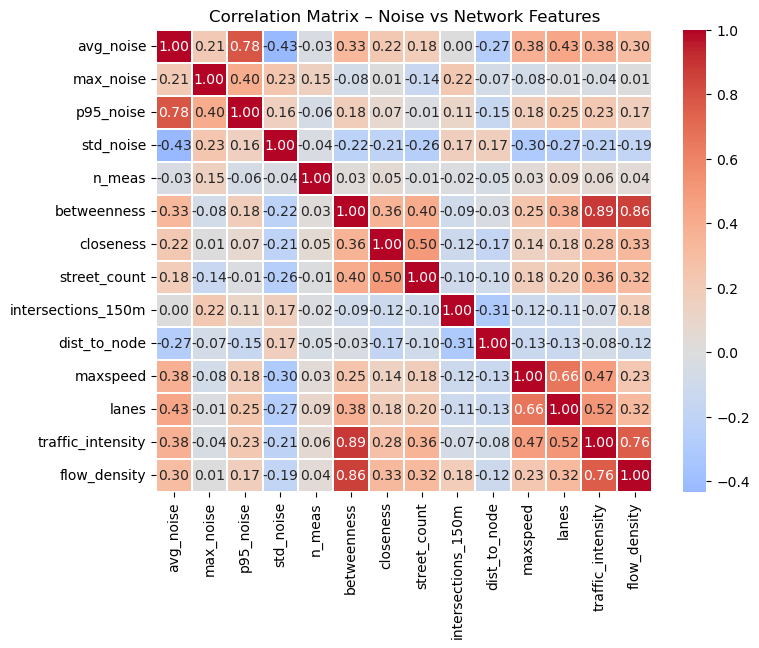

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant features
corr_features = [
    'avg_noise', 'max_noise', 'p95_noise', 'std_noise', 'n_meas',
    'betweenness', 'closeness', 'street_count',
    'intersections_150m', 'dist_to_node', 'maxspeed', 'lanes',
    'traffic_intensity', 'flow_density'
]

# Compute correlation
corr = sensors[corr_features].corr(method='pearson')

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            linewidths=0.3, fmt=".2f")
plt.title("Correlation Matrix – Noise vs Network Features")
plt.show()

In [38]:
sensors.head()

,sensor_id,avg_noise,max_noise,p95_noise,std_noise,n_meas,Latitud,Longitud,geometry,index_right,...,dist_to_node,u,v,key,dist_to_edge,maxspeed,lanes,traffic_intensity,speed_lane_ratio,flow_density
0,186,65.366429,77.4,71.910,4.371013,280,41.395450,2.152752,POINT (429172.394 4583003.569),7917,...,42.156877,4222882539,5094317308,0,5.212726,30.0,1.0,0.408204,30.0,0.022678
1,187,63.641071,72.1,68.505,3.633150,280,41.396156,2.151563,POINT (429073.764 4583082.921),1507,...,10.602728,5094317308,30556617,0,6.611036,30.0,1.0,0.423974,30.0,0.018843
2,206,59.071007,69.6,65.000,3.520876,576,41.380127,2.176924,POINT (431176.967 4581282.954),351,...,22.243886,30243946,4029816820,0,0.024019,30.0,1.0,0.179734,30.0,0.037944
3,207,63.500347,74.2,68.725,3.200402,576,41.378273,2.173348,POINT (430875.987 4581079.972),35,...,7.452369,13134439124,30227025,0,4.510049,30.0,1.0,0.034989,30.0,0.002721
4,208,59.998370,80.3,66.645,4.699822,552,41.384925,2.182772,POINT (431670.986 4581810.993),8877,...,25.313819,13197779092,11298541576,0,4.505727,30.0,1.0,0.116909,30.0,0.011691


### Key Insights from Correlation Matrix

- **Mean noise** correlates most with **lanes** (0.43), **maxspeed** (0.40), and **traffic_intensity** (0.38).
- **Betweenness** (0.34) and **flow_density** (0.29) also relate to noise, confirming the structural influence.
- **Distance to node** has a **negative correlation** with noise (–0.27): sensors further from intersections are quieter.
- Some predictors have high internal correlation (e.g., **betweenness** and **traffic_intensity** at 0.89); avoid using both in the same model.
- **Intersection density** and **closeness** show low correlation with mean noise in this dataset.


## 6. Spatial Statistic Analysis

/home/ivanseldasp/anaconda3/envs/bcn-noise-project/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  warnings.warn(message)


Moran's I: 0.30455287862404534 p-value: 0.001


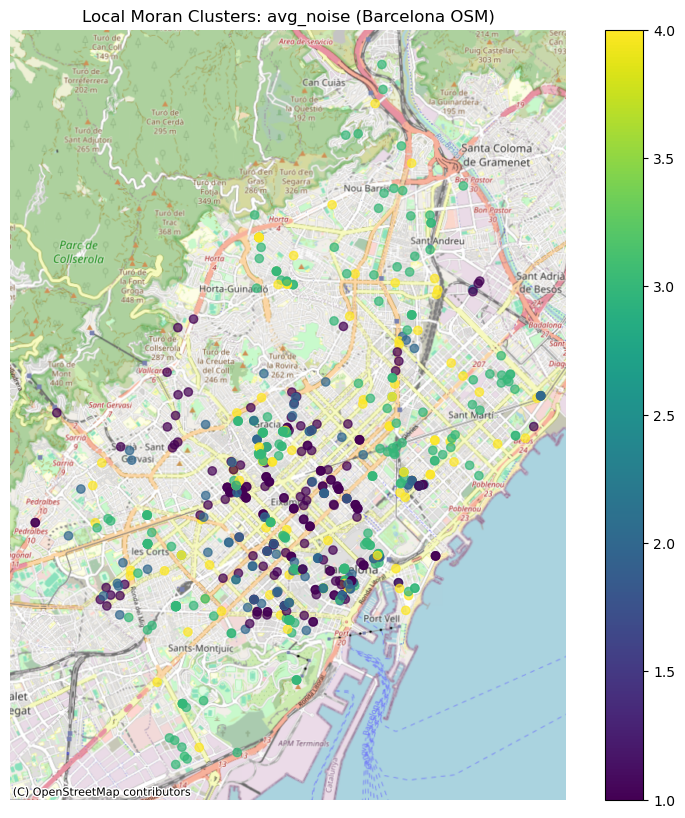

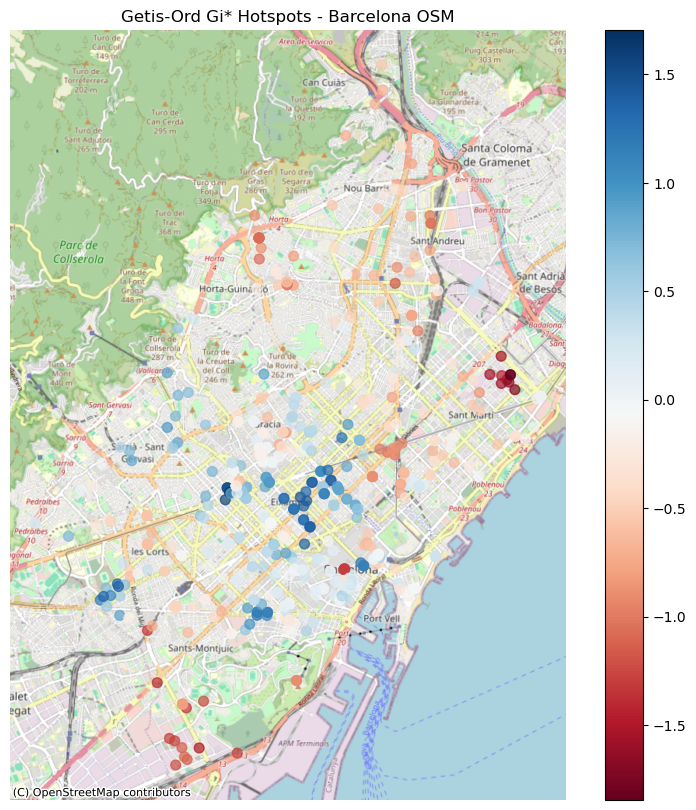

In [59]:
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local
import libpysal
import splot
import contextily as cx
import matplotlib.pyplot as plt

# Project your sensors GeoDataFrame to metric CRS (EPSG:25831 for Barcelona)
if sensors.crs.to_string() != 'EPSG:25831':
    sensors = sensors.to_crs(epsg=25831)

# Build k-nearest neighbors spatial weights (k=6 is standard for urban scale)
w = libpysal.weights.KNN.from_dataframe(sensors, k=6)
w.transform = 'r'

# Global Moran's I (summary of clustering)
mi = Moran(sensors['avg_noise'], w)
print('Moran\'s I:', mi.I, 'p-value:', mi.p_sim)

# Local Moran (LISA) - identifies clusters and spatial outliers
lisa = Moran_Local(sensors['avg_noise'], w)
sensors['lisa_sig'] = lisa.p_sim < 0.05
sensors['lisa_cluster'] = lisa.q

# Plot local Moran clusters
fig, ax = plt.subplots(figsize=(10,10))
sensors.plot(ax=ax, column='lisa_cluster', alpha=0.7, legend=True)
cx.add_basemap(ax, crs=sensors.crs, source=cx.providers.OpenStreetMap.Mapnik)
plt.title("Local Moran Clusters: avg_noise (Barcelona OSM)")
plt.axis('off')
plt.show()

# Getis-Ord Gi* (hotspot/coldspot mapping)
gi = G_Local(sensors['avg_noise'], w)
sensors['gi_z'] = gi.Zs

# Plot Getis-Ord Gi* z-scores as hotspots
fig, ax = plt.subplots(figsize=(10,10))
sensors.plot(ax=ax, column='gi_z', cmap='RdBu', alpha=0.7, markersize=50, legend=True)
cx.add_basemap(ax, crs=sensors.crs, source=cx.providers.OpenStreetMap.Mapnik)
plt.title("Getis-Ord Gi* Hotspots - Barcelona OSM")
plt.axis('off')
plt.show()


In [ ]:
import scipy.stats as stats

corr_gi, pval_gi = stats.pearsonr(sensors['betweenness'], sensors['gi_z'])
corr_moran, pval_moran = stats.pearsonr(sensors['betweenness'], sensors['lisa_cluster'])

print("Betweenness vs Gi*: r =", corr_gi, "p =", pval_gi)
print("Betweenness vs Local Moran's I: r =", corr_moran, "p =", pval_moran)

Betweenness vs Gi*: r = 0.17884046817107846 p = 1.3014756254851099e-06
Betweenness vs Local Moran's I: r = -0.11117369157348225 p = 0.0027586695746658783


In [ ]:
import folium
import branca.colormap as bcm
import matplotlib.pyplot as plt

# Prepare sensors in WGS84
sensors_wgs84 = sensors.to_crs(epsg=4326)

# Set color map and create a color scale
min_z, max_z = sensors_wgs84['gi_z'].min(), sensors_wgs84['gi_z'].max()
colormap = bcm.LinearColormap(
    colors=['blue', 'white', 'red'],  # Or use a continuous matplotlib colormap
    index=[min_z, 0, max_z],
    vmin=min_z, vmax=max_z,
    caption='Gi* z-score (hotspot/coldspot intensity)'
)

# Center the map
mean_lat = sensors_wgs84['geometry'].y.mean()
mean_lon = sensors_wgs84['geometry'].x.mean()
m = folium.Map(location=[mean_lat, mean_lon], zoom_start=13, tiles='OpenStreetMap')

# Add points
for idx, row in sensors_wgs84.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        color=colormap(row['gi_z']),
        fill=True,
        fill_opacity=0.7,
        popup=f"Sensor {row['sensor_id']}<br>avg_noise: {row['avg_noise']:.1f}<br>Gi_z: {row['gi_z']:.2f}"
    ).add_to(m)

# Add color legend to map
colormap.add_to(m)

m.save('bcn_gistar_hotspots_colormap.html')